In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("data.csv")

df.head()

,RowID,Loan_Amount,Term,Interest_Rate,Employment_Years,Home_Ownership,Annual_Income,Verification_Status,Loan_Purpose,State,Debt_to_Income,Delinquent_2yr,Revolving_Cr_Util,Total_Accounts,Bad_Loan,Longest_Credit_Length
0,1,5000.0,36 months,10.65,10.0,RENT,24000.0,VERIFIED - income,credit_card,AZ,27.65,0.0,83.7,9.0,GOOD,26.0
1,2,2500.0,60 months,15.27,0.5,RENT,30000.0,VERIFIED - income source,car,GA,1.00,0.0,9.4,4.0,BAD,12.0
2,3,2400.0,36 months,15.96,10.0,RENT,12252.0,not verified,small_business,IL,8.72,0.0,98.5,10.0,GOOD,10.0
3,4,10000.0,36 months,13.49,10.0,RENT,49200.0,VERIFIED - income source,other,CA,20.00,0.0,21.0,37.0,GOOD,15.0
4,5,5000.0,36 months,7.90,3.0,RENT,36000.0,VERIFIED - income source,wedding,AZ,11.20,0.0,28.3,12.0,GOOD,7.0


In [3]:
df[df['Bad_Loan'] == 'BAD'].iloc[4]

RowID                                          13
Loan_Amount                                 10000
Term                                    36 months
Interest_Rate                               10.65
Employment_Years                                3
Home_Ownership                               RENT
Annual_Income                              100000
Verification_Status      VERIFIED - income source
Loan_Purpose                                other
State                                          CA
Debt_to_Income                               7.06
Delinquent_2yr                                  0
Revolving_Cr_Util                            55.5
Total_Accounts                                 29
Bad_Loan                                      BAD
Longest_Credit_Length                          20
Name: 12, dtype: object

In [4]:
real_cols = [col for col in df.columns if col not in ['Bad_Loan']]
cols_unique_values = {}

for col in real_cols:
    cols_unique_values[col] = df[col].unique()
    
cols_unique_values 

{'RowID': array([     1,      2,      3, ..., 163992, 163993, 163994], dtype=int64),
 'Loan_Amount': array([ 5000.,  2500.,  2400., ..., 26525., 29150., 26875.]),
 'Term': array(['36 months', '60 months', nan], dtype=object),
 'Interest_Rate': array([10.65, 15.27, 15.96, 13.49,  7.9 , 18.64, 21.28, 12.69, 14.65,
         9.91, 16.29,  6.03, 11.71, 12.42, 14.27, 16.77,  7.51,  8.9 ,
        18.25,  6.62, 19.91, 17.27, 17.58, 21.67, 19.42, 20.89, 20.3 ,
        23.91, 19.03, 23.13, 22.35, 22.06, 24.11, 22.74,  6.  , 23.52,
        22.11,  7.49, 11.99,  5.99, 10.99,  9.99, 18.79, 11.49,  8.49,
        15.99, 16.49,  6.99, 15.23, 14.79,  5.42, 10.59, 17.49, 15.62,
        19.29, 12.99, 13.99, 16.89, 17.99, 20.99, 22.85, 19.69, 18.39,
        20.62, 20.25, 21.36, 23.22, 21.74, 22.48, 23.59, 12.62, 18.07,
        11.63,  7.91,  7.42, 11.14, 20.2 , 12.12, 19.39, 16.11, 17.54,
        22.64, 13.84, 16.59, 17.19, 12.87, 20.69,  9.67, 21.82, 19.79,
        18.49, 22.94, 24.4 , 21.48, 14.82, 14.1

In [5]:
# NEW DATA
# X = df.drop("Bad_Loan", axis=1).copy()
# y = df["Bad_Loan"]

In [6]:
# NEW DATA
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, stratify=y, random_state=1)

In [7]:
# NEW DATA
# X_train, X_test, y_train, y_test = train_test_split(X_test, y_test, test_size=0.2, stratify=y_test, random_state=1)

##  Feature Engineering

### Step 1 : Train Test Split

In [8]:
X = df.drop("Bad_Loan", axis=1).copy()
y = df["Bad_Loan"]
y

0         GOOD
1          BAD
2         GOOD
3         GOOD
4         GOOD
          ... 
163989    GOOD
163990    GOOD
163991    GOOD
163992    GOOD
163993    GOOD
Name: Bad_Loan, Length: 163994, dtype: object

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

In [10]:
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

In [11]:
train_data.head()

,RowID,Loan_Amount,Term,Interest_Rate,Employment_Years,Home_Ownership,Annual_Income,Verification_Status,Loan_Purpose,State,Debt_to_Income,Delinquent_2yr,Revolving_Cr_Util,Total_Accounts,Longest_Credit_Length,Bad_Loan
137784,137785,10000.0,36 months,13.35,10.0,MORTGAGE,40000.0,VERIFIED - income source,debt_consolidation,IL,24.21,0.0,85.2,22.0,14.0,GOOD
161255,161256,20000.0,36 months,5.93,0.5,MORTGAGE,95000.0,VERIFIED - income source,home_improvement,AL,10.70,0.0,0.2,42.0,12.0,GOOD
78296,78297,18000.0,60 months,21.49,4.0,MORTGAGE,60300.0,VERIFIED - income,debt_consolidation,SC,17.39,0.0,72.7,15.0,17.0,GOOD
148631,148632,24000.0,36 months,7.62,10.0,MORTGAGE,106000.0,not verified,debt_consolidation,MI,29.30,0.0,69.0,33.0,13.0,GOOD
88888,88889,19000.0,36 months,7.62,10.0,MORTGAGE,120000.0,not verified,credit_card,PA,16.57,0.0,51.0,28.0,23.0,GOOD


In [12]:
test_data.head()

,RowID,Loan_Amount,Term,Interest_Rate,Employment_Years,Home_Ownership,Annual_Income,Verification_Status,Loan_Purpose,State,Debt_to_Income,Delinquent_2yr,Revolving_Cr_Util,Total_Accounts,Longest_Credit_Length,Bad_Loan
125516,125517,10000.0,36 months,8.90,1.0,RENT,37000.0,VERIFIED - income,credit_card,GA,2.26,0.0,52.8,5.0,7.0,GOOD
38558,38559,3000.0,36 months,10.46,10.0,OWN,52200.0,not verified,small_business,IL,4.34,0.0,105.2,9.0,9.0,GOOD
38960,38961,2000.0,36 months,8.38,1.0,RENT,22000.0,not verified,debt_consolidation,FL,13.09,0.0,9.4,6.0,2.0,GOOD
160879,160880,3000.0,36 months,11.99,9.0,MORTGAGE,31600.0,VERIFIED - income,credit_card,NC,11.77,1.0,53.2,22.0,18.0,BAD
48524,48525,12000.0,36 months,12.99,NaN,OWN,85000.0,VERIFIED - income,home_improvement,MI,10.83,0.0,67.5,5.0,3.0,GOOD


### Step 2 : Dropping Columns that are not relevant for prediction

**I am going to drop RowID since it is unique for every record so it does not contain any useful information about target feature.**

In [13]:
def drop_col(dataset, colnames):
    dataset.drop(colnames, axis=1, inplace=True)
    return dataset

In [14]:
train_data = drop_col(train_data, ["RowID"])
test_data = drop_col(test_data, ["RowID"])

In [15]:
train_data.head()

,Loan_Amount,Term,Interest_Rate,Employment_Years,Home_Ownership,Annual_Income,Verification_Status,Loan_Purpose,State,Debt_to_Income,Delinquent_2yr,Revolving_Cr_Util,Total_Accounts,Longest_Credit_Length,Bad_Loan
137784,10000.0,36 months,13.35,10.0,MORTGAGE,40000.0,VERIFIED - income source,debt_consolidation,IL,24.21,0.0,85.2,22.0,14.0,GOOD
161255,20000.0,36 months,5.93,0.5,MORTGAGE,95000.0,VERIFIED - income source,home_improvement,AL,10.70,0.0,0.2,42.0,12.0,GOOD
78296,18000.0,60 months,21.49,4.0,MORTGAGE,60300.0,VERIFIED - income,debt_consolidation,SC,17.39,0.0,72.7,15.0,17.0,GOOD
148631,24000.0,36 months,7.62,10.0,MORTGAGE,106000.0,not verified,debt_consolidation,MI,29.30,0.0,69.0,33.0,13.0,GOOD
88888,19000.0,36 months,7.62,10.0,MORTGAGE,120000.0,not verified,credit_card,PA,16.57,0.0,51.0,28.0,23.0,GOOD


In [16]:
test_data.head()

,Loan_Amount,Term,Interest_Rate,Employment_Years,Home_Ownership,Annual_Income,Verification_Status,Loan_Purpose,State,Debt_to_Income,Delinquent_2yr,Revolving_Cr_Util,Total_Accounts,Longest_Credit_Length,Bad_Loan
125516,10000.0,36 months,8.90,1.0,RENT,37000.0,VERIFIED - income,credit_card,GA,2.26,0.0,52.8,5.0,7.0,GOOD
38558,3000.0,36 months,10.46,10.0,OWN,52200.0,not verified,small_business,IL,4.34,0.0,105.2,9.0,9.0,GOOD
38960,2000.0,36 months,8.38,1.0,RENT,22000.0,not verified,debt_consolidation,FL,13.09,0.0,9.4,6.0,2.0,GOOD
160879,3000.0,36 months,11.99,9.0,MORTGAGE,31600.0,VERIFIED - income,credit_card,NC,11.77,1.0,53.2,22.0,18.0,BAD
48524,12000.0,36 months,12.99,NaN,OWN,85000.0,VERIFIED - income,home_improvement,MI,10.83,0.0,67.5,5.0,3.0,GOOD


### Step 3 : Handling unwanted/strange values

**I will treat strange values like missing values. In Home_Ownership feature there are some strange categories like NONE and ANY. Their frequency is low so i am going to drop the rows that have one of those categories. Dropping only few records is not going to affect the model performance since our dataset is so huge.

In [17]:
for col in train_data.columns:
    print(col + " : ")
    print(train_data[col].unique())

Loan_Amount : 
[10000. 20000. 18000. ... 31675. 24050. 25275.]
Term : 
['36 months' '60 months' nan]
Interest_Rate : 
[13.35  5.93 21.49  7.62  6.62  7.14 21.   12.23  9.25 16.49  8.49 12.35
 14.11 16.32 20.2  16.29 14.09  5.79 14.47 18.25 18.55 15.61 17.74 18.24
 13.11 19.05 11.44 13.99 11.03  6.54 14.99 15.27 13.43 16.99 11.14 11.99
  8.9  14.65 12.99 19.72 16.2  12.12  7.51 15.22 12.53 15.33 15.88 17.27
 22.2  13.05 23.59 15.31 21.99  8.39  9.71  9.76  6.03 19.99 15.99 10.99
 15.8  10.75  9.67 12.42 15.95 17.99 12.69 14.49 11.71 22.47 16.07 23.83
 17.77 19.52 24.99 18.49 17.56 14.98 25.89 14.17 13.53 11.49 10.59 10.65
 13.49 24.08 16.63  6.39 14.35  7.49 17.1  10.16  9.99 13.67 17.57 11.55
 10.37  6.49 21.18 20.3  11.83 18.99 14.72  7.69 15.1   8.88 10.36  7.9
 11.89 12.87 11.67 16.78  6.   15.59  8.6  13.92 12.85 22.95 12.67  9.63
 12.73 12.29 14.16 20.5  19.22 19.2  10.74 14.25  9.17 23.5  10.38 11.86
  5.99 25.99 16.24 20.99  7.68 13.61 13.66 10.15  6.91 13.79 12.49 14.64
 15.58 

In [18]:
print(train_data['Home_Ownership'].unique())
print(test_data['Home_Ownership'].unique())

['MORTGAGE' 'RENT' 'OWN' 'OTHER' 'NONE' nan 'ANY']
['RENT' 'OWN' 'MORTGAGE' 'OTHER' 'NONE' nan]


In [19]:
print(train_data['Home_Ownership'].value_counts())
print(test_data['Home_Ownership'].value_counts())

MORTGAGE    63752
RENT        56448
OWN         10837
OTHER         130
NONE           21
ANY             1
Name: Home_Ownership, dtype: int64
MORTGAGE    15962
RENT        14078
OWN          2723
OTHER          26
NONE            9
Name: Home_Ownership, dtype: int64


In [20]:
# it looks like records with Hoome_Ownership=None are outliers

train_data[train_data['Home_Ownership'] == 'NONE']['Bad_Loan'].value_counts()

GOOD    14
BAD      7
Name: Bad_Loan, dtype: int64

In [21]:
train_data = train_data[(train_data['Home_Ownership'] != 'ANY') & (train_data['Home_Ownership'] != 'NONE')]
test_data = test_data[(test_data['Home_Ownership'] != 'ANY') & (test_data['Home_Ownership'] != 'NONE')]

In [22]:
print(train_data['Home_Ownership'].unique())
print(test_data['Home_Ownership'].unique())

['MORTGAGE' 'RENT' 'OWN' 'OTHER' nan]
['RENT' 'OWN' 'MORTGAGE' 'OTHER' nan]


### Step 4 : Handling Missing Values

**I dropped all the records that have missing values since the amount of missing values is very low (less than 0.5% of data). Dropping only few records is not going to affect the model performance since our dataset is so huge.**

In [23]:
def check_for_missing_values(dataset):
    
    if dataset.isna().sum().any():

        df_nan_values = pd.DataFrame()

        for col in dataset.columns:
            nr_nan_values_percentage = dataset[col].isna().mean()
            nr_nan_values = dataset[col].isna().sum()

            if nr_nan_values > 0:
                row = {'Feature' : col, 
                       'Percentage Nan Values' : nr_nan_values_percentage, 
                       'Amount Nan Values' : nr_nan_values}
                df_nan_values = df_nan_values.append(row, ignore_index=True)


        df_nan_values.to_csv('mycsv.csv', index=False)
        
        return True
    
    else:
        return False

In [24]:
if check_for_missing_values(df):
    print('There are missing values')
else:
    print('There are no missing values')

There are missing values


In [25]:
features_with_na=[features for features in train_data.columns if train_data[features].isnull().sum()>0]
print(len(features_with_na))
print(features_with_na)
print(len(train_data.columns))

14
['Loan_Amount', 'Term', 'Interest_Rate', 'Employment_Years', 'Home_Ownership', 'Annual_Income', 'Verification_Status', 'Loan_Purpose', 'State', 'Debt_to_Income', 'Delinquent_2yr', 'Revolving_Cr_Util', 'Total_Accounts', 'Longest_Credit_Length']
15


In [26]:
features_with_na=[features for features in test_data.columns if test_data[features].isnull().sum()>0]
print(len(features_with_na))
print(features_with_na)
print(len(test_data.columns))

14
['Loan_Amount', 'Term', 'Interest_Rate', 'Employment_Years', 'Home_Ownership', 'Annual_Income', 'Verification_Status', 'Loan_Purpose', 'State', 'Debt_to_Income', 'Delinquent_2yr', 'Revolving_Cr_Util', 'Total_Accounts', 'Longest_Credit_Length']
15


In [27]:
## 2- step print the feature name and the percentage of missing values

for feature in features_with_na:
    print(feature, np.round(train_data[feature].isnull().mean(), 4),  ' % missing values')

Loan_Amount 0.0  % missing values
Term 0.0  % missing values
Interest_Rate 0.0  % missing values
Employment_Years 0.0358  % missing values
Home_Ownership 0.0  % missing values
Annual_Income 0.0  % missing values
Verification_Status 0.0  % missing values
Loan_Purpose 0.0  % missing values
State 0.0  % missing values
Debt_to_Income 0.0  % missing values
Delinquent_2yr 0.0002  % missing values
Revolving_Cr_Util 0.0012  % missing values
Total_Accounts 0.0002  % missing values
Longest_Credit_Length 0.0002  % missing values


In [28]:
## 2- step print the feature name and the percentage of missing values

for feature in features_with_na:
    print(feature, np.round(test_data[feature].isnull().mean(), 4),  ' % missing values')

Loan_Amount 0.0  % missing values
Term 0.0  % missing values
Interest_Rate 0.0  % missing values
Employment_Years 0.034  % missing values
Home_Ownership 0.0  % missing values
Annual_Income 0.0  % missing values
Verification_Status 0.0  % missing values
Loan_Purpose 0.0  % missing values
State 0.0  % missing values
Debt_to_Income 0.0  % missing values
Delinquent_2yr 0.0002  % missing values
Revolving_Cr_Util 0.0012  % missing values
Total_Accounts 0.0002  % missing values
Longest_Credit_Length 0.0002  % missing values


In [29]:
# drop all rows of dataframe that have at least one missing value
def drop_missing_values(dataset):
    dataset.dropna(inplace=True)
    return dataset

In [30]:
train_data = drop_missing_values(train_data)
test_data = drop_missing_values(test_data)

In [31]:
train_data.isna().sum()

Loan_Amount              0
Term                     0
Interest_Rate            0
Employment_Years         0
Home_Ownership           0
Annual_Income            0
Verification_Status      0
Loan_Purpose             0
State                    0
Debt_to_Income           0
Delinquent_2yr           0
Revolving_Cr_Util        0
Total_Accounts           0
Longest_Credit_Length    0
Bad_Loan                 0
dtype: int64

In [32]:
test_data.isna().sum()

Loan_Amount              0
Term                     0
Interest_Rate            0
Employment_Years         0
Home_Ownership           0
Annual_Income            0
Verification_Status      0
Loan_Purpose             0
State                    0
Debt_to_Income           0
Delinquent_2yr           0
Revolving_Cr_Util        0
Total_Accounts           0
Longest_Credit_Length    0
Bad_Loan                 0
dtype: int64

### Step 5 : Encoding Categorical Features

In [33]:
train_data.dtypes

Loan_Amount              float64
Term                      object
Interest_Rate            float64
Employment_Years         float64
Home_Ownership            object
Annual_Income            float64
Verification_Status       object
Loan_Purpose              object
State                     object
Debt_to_Income           float64
Delinquent_2yr           float64
Revolving_Cr_Util        float64
Total_Accounts           float64
Longest_Credit_Length    float64
Bad_Loan                  object
dtype: object

In [34]:
# encoding target feature
train_data['Bad_Loan'] = train_data['Bad_Loan'].map({'BAD' : 1, "GOOD" : 0})
test_data['Bad_Loan'] = test_data['Bad_Loan'].map({'BAD' : 1, "GOOD" : 0})

In [35]:
numerical_features = [feature for feature in train_data.columns if train_data[feature].dtypes != 'O']
print(numerical_features)
print(len(numerical_features))

['Loan_Amount', 'Interest_Rate', 'Employment_Years', 'Annual_Income', 'Debt_to_Income', 'Delinquent_2yr', 'Revolving_Cr_Util', 'Total_Accounts', 'Longest_Credit_Length', 'Bad_Loan']
10


In [36]:
## Numerical variables are usually of 2 type
## 1. Continous variable and Discrete Variables

discrete_feature=[feature for feature in numerical_features if len(train_data[feature].unique())<25]
print(len(discrete_feature))
print(discrete_feature)

3
['Employment_Years', 'Delinquent_2yr', 'Bad_Loan']


In [37]:
categorical_features=[feature for feature in train_data.columns if train_data[feature].dtypes=='O']
print(len(categorical_features))
print(categorical_features)

5
['Term', 'Home_Ownership', 'Verification_Status', 'Loan_Purpose', 'State']


**Term is a ordinal categorical feature. I encoded it be taking the number from the string 'x months'.**

In [38]:
# Term is a ordinal categorical feature
print(train_data["Term"].unique())
print(test_data["Term"].unique())

['36 months' '60 months']
['36 months' '60 months']


In [39]:
train_data["Term"] = train_data["Term"].map({'36 months' : 36, '60 months' : 60})
test_data["Term"] = test_data["Term"].map({'36 months' : 36, '60 months' : 60})

In [40]:
# Home_Ownership is a nominal categorical feature
print(train_data["Home_Ownership"].unique())
print(test_data["Home_Ownership"].unique())

['MORTGAGE' 'RENT' 'OWN' 'OTHER']
['RENT' 'OWN' 'MORTGAGE' 'OTHER']


In [41]:
# NEW DATA
# train_data = train_data[(train_data['Home_Ownership'] != 'NONE') & (train_data['Home_Ownership'] != 'OTHER')]

**Verification_Status is a nominal categorical feature. The number of categories is low (3). I am going to use one-hot encoding to encode it into numerical since we have only 4 categories and we would not increase the nr of features that much.**

In [42]:
# Verification_Status is a nominal categorical feature
print(train_data["Verification_Status"].unique())
print(test_data["Verification_Status"].unique())

['VERIFIED - income source' 'VERIFIED - income' 'not verified']
['VERIFIED - income' 'not verified' 'VERIFIED - income source']


**Loan Purpose is a nominal categorical feature. The number of categories is not high. I am going to use one-hot encoding to encode it into numerical since we have only few categories and we would not increase the nr of features that much.

In [43]:
# Loan Purpose is a nominal categorical feature
print(train_data["Loan_Purpose"].unique())
print(test_data["Loan_Purpose"].unique())
print(len(train_data["Loan_Purpose"].unique()))
print(len(test_data["Loan_Purpose"].unique()))

['debt_consolidation' 'home_improvement' 'credit_card' 'other'
 'small_business' 'educational' 'major_purchase' 'moving' 'vacation' 'car'
 'house' 'wedding' 'medical' 'renewable_energy']
['credit_card' 'small_business' 'debt_consolidation' 'major_purchase'
 'other' 'home_improvement' 'vacation' 'medical' 'car' 'house' 'moving'
 'wedding' 'renewable_energy' 'educational']
14
14


In [44]:
# NEW DATA
#train_data = train_data[train_data['Loan_Purpose'] != 'renewable_energy']

In [45]:
# NEW DATA
#[cat for cat in train_data['Loan_Purpose'].unique() if cat not in test_data['Loan_Purpose'].unique()]

**State is a nominal categorical feature but it has many categories so we can not use one-hot encoding because that would highly increase the nr of dummy features. Instead i will use mean encoding by taking for each category the mean of target feature and assigning it that category.**
**Test Data has 1 category less than train data. Since we will use mean encoding well not face any error.**

**Note:**<br>
To avoid data leakage we use the same dictionary (means) that we calculated in training set for the test set. We should not calculate the mean of each category in test set because we dont want our model to have knowledge about test set.

In [46]:

print(X_train['State'].unique())
print(X_test['State'].unique())
print(len(X_train['State'].unique()))
print(len(X_test['State'].unique()))

['IL' 'AL' 'SC' 'MI' 'PA' 'MN' 'NY' 'OR' 'NV' 'LA' 'NC' 'MA' 'FL' 'CA'
 'WY' 'TX' 'GA' 'AK' 'OK' 'NJ' 'VA' 'OH' 'NH' 'WA' 'MO' 'NM' 'MD' 'AZ'
 'UT' 'WV' 'CT' 'SD' 'IN' 'CO' 'HI' 'RI' 'DE' 'DC' 'KS' 'WI' 'TN' 'MT'
 'KY' 'AR' 'MS' 'VT' 'ID' 'IA' nan 'ME' 'NE']
['GA' 'IL' 'FL' 'NC' 'MI' 'TX' 'MD' 'SD' 'MN' 'RI' 'CO' 'CA' 'PA' 'NY'
 'VA' 'WA' 'OK' 'AZ' 'OH' 'MA' 'IN' 'CT' 'LA' 'MO' 'NJ' 'WI' 'AL' 'UT'
 'HI' 'KY' 'OR' 'NV' 'NH' 'WV' 'AR' 'WY' 'TN' 'NM' 'MS' 'SC' 'KS' 'MT'
 'DC' 'DE' 'VT' 'AK' 'NE' 'ID' 'IA' nan]
51
50


In [47]:
train_data.groupby('State')['Bad_Loan'].sum()

State
AK      53
AL     312
AR     165
AZ     507
CA    3869
CO     390
CT     324
DC      54
DE      58
FL    1821
GA     696
HI     148
IA       1
ID       1
IL     811
IN     230
KS     178
KY     240
LA     264
MA     562
MD     555
ME       0
MI     561
MN     370
MO     381
MS      30
MT      49
NC     630
NE       5
NH      99
NJ    1007
NM     118
NV     412
NY    2055
OH     699
OK     206
OR     263
PA     734
RI     104
SC     225
SD      47
TN     253
TX    1462
UT     187
VA     697
VT      40
WA     504
WI     262
WV      66
WY      29
Name: Bad_Loan, dtype: int64

In [48]:
train_data.groupby('State')['Bad_Loan'].mean()

State
AK    0.163077
AL    0.209677
AR    0.198317
AZ    0.170306
CA    0.174917
CO    0.143067
CT    0.162651
DC    0.114165
DE    0.174699
FL    0.208448
GA    0.177009
HI    0.200814
IA    0.142857
ID    0.200000
IL    0.171677
IN    0.207957
KS    0.173320
KY    0.206186
LA    0.184100
MA    0.173618
MD    0.180900
ME    0.000000
MI    0.196497
MN    0.174776
MO    0.188707
MS    0.234375
MT    0.132791
NC    0.184157
NE    0.454545
NH    0.166387
NJ    0.201038
NM    0.184664
NV    0.224646
NY    0.187039
OH    0.185411
OK    0.204365
OR    0.160268
PA    0.174347
RI    0.189435
SC    0.158451
SD    0.199153
TN    0.254271
TX    0.155631
UT    0.171245
VA    0.170624
VT    0.188679
WA    0.172072
WI    0.170573
WV    0.120879
WY    0.104317
Name: Bad_Loan, dtype: float64

In [49]:
dic_state = train_data.groupby('State')['Bad_Loan'].mean().to_dict()
dic_state

{'AK': 0.16307692307692306,
 'AL': 0.20967741935483872,
 'AR': 0.19831730769230768,
 'AZ': 0.1703056768558952,
 'CA': 0.17491749174917492,
 'CO': 0.14306676449009537,
 'CT': 0.16265060240963855,
 'DC': 0.11416490486257928,
 'DE': 0.1746987951807229,
 'FL': 0.2084478021978022,
 'GA': 0.1770091556459817,
 'HI': 0.20081411126187246,
 'IA': 0.14285714285714285,
 'ID': 0.2,
 'IL': 0.17167654530059273,
 'IN': 0.20795660036166366,
 'KS': 0.1733203505355404,
 'KY': 0.20618556701030927,
 'LA': 0.18410041841004185,
 'MA': 0.17361754711152302,
 'MD': 0.18089960886571055,
 'ME': 0.0,
 'MI': 0.19649737302977233,
 'MN': 0.1747756258856873,
 'MO': 0.1887072808320951,
 'MS': 0.234375,
 'MT': 0.13279132791327913,
 'NC': 0.1841566793335282,
 'NE': 0.45454545454545453,
 'NH': 0.16638655462184873,
 'NJ': 0.20103813136354562,
 'NM': 0.18466353677621283,
 'NV': 0.22464558342420937,
 'NY': 0.1870392281787567,
 'OH': 0.18541114058355437,
 'OK': 0.20436507936507936,
 'OR': 0.16026812918951858,
 'PA': 0.1743467

In [50]:
train_data["State"] = train_data["State"].map(dic_state)
test_data["State"] = test_data["State"].map(dic_state)

In [51]:
print(len(train_data.columns))
print(len(test_data.columns))

15
15


In [52]:
train_data = pd.get_dummies(train_data, columns=['Home_Ownership', 'Verification_Status', 'Loan_Purpose'])
test_data = pd.get_dummies(test_data, columns=['Home_Ownership', 'Verification_Status', 'Loan_Purpose'])

In [53]:
np.array_equal(X_train.columns, X_test.columns)

True

In [54]:
print(len(train_data.columns))
print(len(test_data.columns))

33
33


In [55]:
train_data.head()

,Loan_Amount,Term,Interest_Rate,Employment_Years,Annual_Income,State,Debt_to_Income,Delinquent_2yr,Revolving_Cr_Util,Total_Accounts,...,Loan_Purpose_home_improvement,Loan_Purpose_house,Loan_Purpose_major_purchase,Loan_Purpose_medical,Loan_Purpose_moving,Loan_Purpose_other,Loan_Purpose_renewable_energy,Loan_Purpose_small_business,Loan_Purpose_vacation,Loan_Purpose_wedding
137784,10000.0,36,13.35,10.0,40000.0,0.171677,24.21,0.0,85.2,22.0,...,0,0,0,0,0,0,0,0,0,0
161255,20000.0,36,5.93,0.5,95000.0,0.209677,10.70,0.0,0.2,42.0,...,1,0,0,0,0,0,0,0,0,0
78296,18000.0,60,21.49,4.0,60300.0,0.158451,17.39,0.0,72.7,15.0,...,0,0,0,0,0,0,0,0,0,0
148631,24000.0,36,7.62,10.0,106000.0,0.196497,29.30,0.0,69.0,33.0,...,0,0,0,0,0,0,0,0,0,0
88888,19000.0,36,7.62,10.0,120000.0,0.174347,16.57,0.0,51.0,28.0,...,0,0,0,0,0,0,0,0,0,0


In [56]:
test_data.head()

,Loan_Amount,Term,Interest_Rate,Employment_Years,Annual_Income,State,Debt_to_Income,Delinquent_2yr,Revolving_Cr_Util,Total_Accounts,...,Loan_Purpose_home_improvement,Loan_Purpose_house,Loan_Purpose_major_purchase,Loan_Purpose_medical,Loan_Purpose_moving,Loan_Purpose_other,Loan_Purpose_renewable_energy,Loan_Purpose_small_business,Loan_Purpose_vacation,Loan_Purpose_wedding
125516,10000.0,36,8.90,1.0,37000.0,0.177009,2.26,0.0,52.8,5.0,...,0,0,0,0,0,0,0,0,0,0
38558,3000.0,36,10.46,10.0,52200.0,0.171677,4.34,0.0,105.2,9.0,...,0,0,0,0,0,0,0,1,0,0
38960,2000.0,36,8.38,1.0,22000.0,0.208448,13.09,0.0,9.4,6.0,...,0,0,0,0,0,0,0,0,0,0
160879,3000.0,36,11.99,9.0,31600.0,0.184157,11.77,1.0,53.2,22.0,...,0,0,0,0,0,0,0,0,0,0
38416,7000.0,36,15.45,0.5,30000.0,0.155631,18.80,0.0,41.0,30.0,...,0,0,0,0,0,0,0,0,0,0


In [57]:
X_train = train_data.drop('Bad_Loan', axis=1)
y_train = train_data['Bad_Loan']
X_test = test_data.drop('Bad_Loan', axis=1)
y_test = test_data['Bad_Loan']

In [58]:
X_train.columns

Index(['Loan_Amount', 'Term', 'Interest_Rate', 'Employment_Years',
       'Annual_Income', 'State', 'Debt_to_Income', 'Delinquent_2yr',
       'Revolving_Cr_Util', 'Total_Accounts', 'Longest_Credit_Length',
       'Home_Ownership_MORTGAGE', 'Home_Ownership_OTHER', 'Home_Ownership_OWN',
       'Home_Ownership_RENT', 'Verification_Status_VERIFIED - income',
       'Verification_Status_VERIFIED - income source',
       'Verification_Status_not verified', 'Loan_Purpose_car',
       'Loan_Purpose_credit_card', 'Loan_Purpose_debt_consolidation',
       'Loan_Purpose_educational', 'Loan_Purpose_home_improvement',
       'Loan_Purpose_house', 'Loan_Purpose_major_purchase',
       'Loan_Purpose_medical', 'Loan_Purpose_moving', 'Loan_Purpose_other',
       'Loan_Purpose_renewable_energy', 'Loan_Purpose_small_business',
       'Loan_Purpose_vacation', 'Loan_Purpose_wedding'],
      dtype='object')

##  Feature Selection

### Step 6:  Feature Selection using Recursive Elemination with Cross Validation

**To select only the most important features i will use Recursive Elemination with CV. First it will sort the features from the most important to least important by calculating feature importances using impurity measurament. Then it will select all the features, perform CV, measure the accuracy and then decrease the nr of features by x and do the same thing. It will compare the accuracys. If it decreases when we remove features it will stop and select the most important features.**

In [59]:
from sklearn.feature_selection import RFECV
from xgboost import XGBRegressor

def feature_selection_recursive_elemination_cv(model, X_train, y_train, X_test, scoring, step=1, min_features_to_select=1, 
                                               cv_kfold=5, verbose=False):
    try:
        print('Entered function feature_selection_recursive_elemination_cv.')

        total_nr_features = X_train.shape[1]
        selector = RFECV(model, step=step, min_features_to_select=min_features_to_select, cv=cv_kfold, scoring=scoring, 
                         n_jobs=-1, verbose=verbose)
        selector.fit(X_train, y_train)
        nr_features_selected = selector.n_features_
        print(str(nr_features_selected) + ' out of total ' + str(total_nr_features))
    
        dicti = {}
        for col, ranking in zip(X_train.columns, selector.ranking_):
            dicti[col] = ranking
    
    
        cols_selected = X_train.columns[selector.support_]
        
        print('Features selected : ')
        print(cols_selected)
        new_X_train = X_train[cols_selected]
        new_X_test = X_test[cols_selected]
        
        
        print('Function feature_selection_recursive_elemination_cv Completed Successfully. Exited this function.')
        return new_X_train, new_X_test
    
    except Exception as e:
        print('Error occured in function feature_selection_recursive_elemination_cv. Error Message : ' + str(e))

In [60]:
# from xgboost import XGBClassifier

# s = len(y_train[y_train] == 0) / len(y_train[y_train == 1])
# model = XGBClassifier(random_state=1, scale_pos_weight=s)
# X_train, X_test = feature_selection_recursive_elemination_cv(model=model, X_train=X_train, y_train=y_train, X_test=X_test, scoring='roc_auc')

In [61]:
X_train.drop('Home_Ownership_OTHER', axis=1, inplace=True)
X_test.drop('Home_Ownership_OTHER', axis=1, inplace=True)

In [62]:
print(X_train.shape)
print(X_test.shape)

(126329, 31)
(31641, 31)


In [63]:
updated_cols = X_train.columns
updated_cols

Index(['Loan_Amount', 'Term', 'Interest_Rate', 'Employment_Years',
       'Annual_Income', 'State', 'Debt_to_Income', 'Delinquent_2yr',
       'Revolving_Cr_Util', 'Total_Accounts', 'Longest_Credit_Length',
       'Home_Ownership_MORTGAGE', 'Home_Ownership_OWN', 'Home_Ownership_RENT',
       'Verification_Status_VERIFIED - income',
       'Verification_Status_VERIFIED - income source',
       'Verification_Status_not verified', 'Loan_Purpose_car',
       'Loan_Purpose_credit_card', 'Loan_Purpose_debt_consolidation',
       'Loan_Purpose_educational', 'Loan_Purpose_home_improvement',
       'Loan_Purpose_house', 'Loan_Purpose_major_purchase',
       'Loan_Purpose_medical', 'Loan_Purpose_moving', 'Loan_Purpose_other',
       'Loan_Purpose_renewable_energy', 'Loan_Purpose_small_business',
       'Loan_Purpose_vacation', 'Loan_Purpose_wedding'],
      dtype='object')

In [64]:
encoded_features = {}
encoded_features['Loan_Amount'] = ['Loan_Amount']
encoded_features['Term'] = ['Term']
encoded_features['Interest_Rate'] = ['Interest_Rate']
encoded_features['Employment_Years'] = ['Employment_Years']
encoded_features['Annual_Income'] = ['Annual_Income']
encoded_features['State'] = ['State']
encoded_features['Debt_to_Income'] = ['Debt_to_Income']
encoded_features['Delinquent_2yr'] = ['Delinquent_2yr']
encoded_features['Revolving_Cr_Util'] = ['Revolving_Cr_Util']
encoded_features['Total_Accounts'] = ['Total_Accounts']
encoded_features['Longest_Credit_Length'] = ['Longest_Credit_Length']
encoded_features['Home_Ownership'] = ['Home_Ownership_MORTGAGE', 'Home_Ownership_OWN', 'Home_Ownership_RENT']
encoded_features['Verification_Status'] = ['Verification_Status_VERIFIED - income', 'Verification_Status_VERIFIED - income source',
                                           'Verification_Status_not verified']

encoded_features['Loan_Purpose'] = ['Loan_Purpose_car', 'Loan_Purpose_credit_card', 'Loan_Purpose_debt_consolidation',
                                    'Loan_Purpose_educational', 'Loan_Purpose_home_improvement',
                                    'Loan_Purpose_house', 'Loan_Purpose_major_purchase',
                                     'Loan_Purpose_medical', 'Loan_Purpose_moving', 'Loan_Purpose_other',
                                     'Loan_Purpose_renewable_energy', 'Loan_Purpose_small_business',
                                     'Loan_Purpose_vacation', 'Loan_Purpose_wedding']

print(encoded_features)

{'Loan_Amount': ['Loan_Amount'], 'Term': ['Term'], 'Interest_Rate': ['Interest_Rate'], 'Employment_Years': ['Employment_Years'], 'Annual_Income': ['Annual_Income'], 'State': ['State'], 'Debt_to_Income': ['Debt_to_Income'], 'Delinquent_2yr': ['Delinquent_2yr'], 'Revolving_Cr_Util': ['Revolving_Cr_Util'], 'Total_Accounts': ['Total_Accounts'], 'Longest_Credit_Length': ['Longest_Credit_Length'], 'Home_Ownership': ['Home_Ownership_MORTGAGE', 'Home_Ownership_OWN', 'Home_Ownership_RENT'], 'Verification_Status': ['Verification_Status_VERIFIED - income', 'Verification_Status_VERIFIED - income source', 'Verification_Status_not verified'], 'Loan_Purpose': ['Loan_Purpose_car', 'Loan_Purpose_credit_card', 'Loan_Purpose_debt_consolidation', 'Loan_Purpose_educational', 'Loan_Purpose_home_improvement', 'Loan_Purpose_house', 'Loan_Purpose_major_purchase', 'Loan_Purpose_medical', 'Loan_Purpose_moving', 'Loan_Purpose_other', 'Loan_Purpose_renewable_energy', 'Loan_Purpose_small_business', 'Loan_Purpose_va

### Step 7 Model Tuning, Creation and Evaluation

* These functions are needed to tune the ML Estimators.

In [65]:
def train_model(model, X_train, y_train):
    try:
        print('Entered the function train_model')
        model.fit(X_train, y_train)
        
        print('Function train_model Completed Successfully! Exited this function.')
        return model
    except Exception as e:
        print('Error occured in function train_model. Error Messaeg : ' + str(e))

In [66]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import plot_confusion_matrix, classification_report
import os
import shutil
import matplotlib.pyplot as plt

def evaluate_model_classification(model, path, model_name, X, y):
    try:
        print('Entered function evaluate_model_classification.')
        
        pred = model.predict(X)
        score = roc_auc_score(y, pred)  # scoring is chosen based on the problem statement. In this case we use auc score.
            
        parent_path = model_name + '_ConfusionMatrices/'
        if os.path.exists(parent_path) == False:
            os.mkdir(parent_path)
        
            
        model_path = parent_path + path 
        if os.path.exists(model_path):
            shutil.rmtree(model_path, ignore_errors=False, onerror=None)
            os.mkdir(model_path)
        else:
            os.mkdir(model_path)
            
        print(classification_report(y, pred))
        plt.figure(figsize=(15,12))
        plot_confusion_matrix(model, X, y)
        plt.savefig(model_path+'confusion_matrix.jpg')
        
        print('Function evaluate_model_classification Completed Successfully. Exited this function')
        
        return score
    
    except Exception as e:
        print('Error occured in function evaluate_model_classification. Error Message : '+str(e))

In [67]:
from sklearn.model_selection import cross_val_score

def evaluate_model_cross_validation(model, X_train, y_train, scoring, cv=5, verbose=False):
    try:
        print('Entered function evaluate_model_cross_validation.')
        scores = cross_val_score(model, X_train, y_train, scoring=scoring, cv=cv, n_jobs=-1, verbose=verbose)
    
        print('Function evaluate_model_cross_validation Completed Successfully.Exited this function.')
        
    except Exception as e:
        print('Error occured in function evaluate_model_cross_validation. Error Message : '+str(e))
    return scores

In [68]:
from sklearn.model_selection import RandomizedSearchCV

def HyperparameterTuning_RandomizedSearchCV(X_train, y_train, model, params, scoring, n_iter=20, cv=5, verbose=False):
    try:
        print('Entered the function HyperparameterTuning_RandomizedSearchCV.')
        
        search = RandomizedSearchCV(model, params, n_iter=n_iter, scoring=scoring, 
                                cv=cv, n_jobs=-1, verbose=verbose, random_state=1)
    
        
        search.fit(X_train, y_train)
        model.set_params(**search.best_params_)
    
        dic = {'tuned_model' : model,
               'best_hyperparameters' : search.best_params_,
               'best_cv_score' : search.best_score_}
        
        print('Function HyperparameterTuning_RandomizedSearchCV Completed Successfully! Exited this function.')
        return dic
    
    except Exception as e:
        print('Error occured in function HyperparameterTuning_RandomizedSearchCV. Error message : ' + str(e))

In [69]:
from sklearn.base import clone
import numpy as np
from sklearn import tree
import matplotlib.pyplot as plt
import os
import shutil

def best_single_model_RandomizedSearchCV(X_train, y_train, X_test, y_test, model_name, defaultModel, params, 
                                         cv_scoring, cv_kfold=5, cv_n_iter=20):
    
    try:
        print('Entered function best_single_model_RandomizedSearchCV. ')        
            
        # create copies of default model object to avoid unwanted changes
        def_model = clone(defaultModel)
        tun_model = clone(defaultModel)
    
        # 1. Default Model   
        # A) Evaluate model using cross validation
        default_model_cv_scores = evaluate_model_cross_validation(def_model, X_train, y_train, scoring=cv_scoring,
                                                                 cv=cv_kfold)
        default_model_cv_mean_score = np.mean(default_model_cv_scores)
        
        # B) Train KNN model with default hyperparameters
        default_model = train_model(def_model, X_train, y_train)
    
        # C) evaluate the model on test set and training set
        print(f'Default {model_name} Model Performance on TEST SET : ')
        
        # in case of regression we should remove the line about the confusion matrix path and change the evaluation model function
        Path_DefaultModel_TestData = 'DefaultModel_TestData_ConfusionMatrix/'
        default_model_test_score = evaluate_model_classification(default_model, Path_DefaultModel_TestData, model_name, X_test, y_test)
        
        print(f'Default {model_name} Model Performance on TRAINING SET : ')
        # in case of regression we should remove the line about the confusion matrix path and change the evaluation model function
        Path_DefaultModel_TrainingData = 'DefaultModel_TrainingData_ConfusionMatrix/'
        default_model_training_score = evaluate_model_classification(default_model, Path_DefaultModel_TrainingData, model_name,
                                                      X_train, y_train)
    
        
        # 2. Tuned Model
        # If we want to use Optuna to tune Hyperparameters we call model_optuna function
        # A) Tune the model
        dic = HyperparameterTuning_RandomizedSearchCV(X_train=X_train, y_train=y_train, model=tun_model, 
                                       params=params, n_iter=cv_n_iter, scoring=cv_scoring, cv=cv_kfold, verbose=True)
        tunedModel = dic['tuned_model']
        best_params = dic['best_hyperparameters']
        tuned_model_cv_mean_score = dic['best_cv_score']
        
        # B) Calculate the cross validation scores and mean on training set
        tuned_model_cv_scores = evaluate_model_cross_validation(tunedModel, X_train, y_train, scoring=cv_scoring,
                                                                cv=cv_kfold)
        
        # B) Train the tuned model on training set
        tuned_model = train_model(tunedModel, X_train, y_train)
        
        # C) Evaluate the model on test set and training set
        print(f'Tuned Model {model_name} Performance on TEST SET : ')
        # in case of regression we should remove the line about the confusion matrix path and change the evaluation model function
        Path_TunedModel_TestData = 'TunedModel_TestData_ConfusionMatrix/'
        tuned_model_test_score = evaluate_model_classification(tuned_model, Path_TunedModel_TestData, model_name, X_test, y_test)
        
        print(f'Tuned Model {model_name} Performance on TRAINING SET : ')
        # in case of regression we should remove the line about the confusion matrix path and change the evaluation model function
        Path_TunedModel_TrainingData = 'TunedModel_TrainingData_ConfusionMatrix/'
        tuned_model_training_score = evaluate_model_classification(tuned_model, Path_TunedModel_TrainingData,
                                                    model_name, X_train, y_train)
        
        # Find the best model with best score
        if tuned_model_test_score >= default_model_test_score:
            best_model_name = 'Tuned Model'
            best_model_object = tuned_model
            
        else:
            best_model_name = 'Default Model'
            best_model_object = default_model
    
        model_infos = {'Model Name' : model_name,
                       'Default Model Object' : default_model,
                       'Default Model Test Score' : default_model_test_score,
                       'Default Model Training Score' : default_model_training_score,
                       'Default Model CV Mean Score' : default_model_cv_mean_score,
                       'Default Model CV Scores' : default_model_cv_scores,
                       'Tuned Model Object' : tuned_model,
                       'Best Hyperparameters' : best_params,
                       'Tuned Model CV Mean Score' : tuned_model_cv_mean_score,
                       'Tuned Model CV Scores' : tuned_model_cv_scores,
                       'Tuned Model Test Score' : tuned_model_test_score,
                       'Tuned Model Training Score' : tuned_model_training_score,
                       'Final Best Model Name' : best_model_name,
                       'Final Best Test Score' : max(tuned_model_test_score, default_model_test_score),
                       'Final Best Model Object' : best_model_object}
                
        
        print('Function best_single_model_RandomizedSearchCV Completed Successfully. Exited this function.')
        return model_infos
    
        
    except Exception as e:
        print('Error occured in function best_single_model_RandomizedSearchCV. Error message : ' + str(e))

In [70]:
from matplotlib.legend_handler import HandlerLine2D
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil

def tuning_single_hyperparameter(model, path, X_train, y_train, hyperparameter_name, hyperparameter_space, scoring, 
                                 cv=5, verbose=False, graph=True):
    try:
        print('Entered function tuning_single_hyperparameter.')
        
        parent_path = 'Single_Hyperparameter_Tuning/'
        if os.path.exists(parent_path) == False:
            os.mkdir(parent_path)
        
        
        model_path = parent_path + path 
        if os.path.exists(model_path) == False:
            os.mkdir(model_path)
            

        
        train_scores = []
        validation_scores = []
        

        #max_depth = [3, 5, 7, 9, 11, 13, 15]
        for x in hyperparameter_space:
            dic = {hyperparameter_name : x}
            model.set_params(**dic)
            scores = cross_validate(model, X_train, y_train, scoring=scoring,
                                  cv=cv, return_train_score=True, n_jobs=-1, verbose=verbose)
    
            train_scores.append(np.mean(scores['train_score']))
            validation_scores.append(np.mean(scores['test_score']))
        
        
            
        if graph:
        
            line1, = plt.plot(hyperparameter_space, train_scores, 'b', label='Train AUC')
            line2, = plt.plot(hyperparameter_space, validation_scores, 'r', label='Validation AUC')
            plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
            plt.ylabel(scoring)
            plt.xlabel(hyperparameter_name)
            plt.savefig(model_path + hyperparameter_name + '_graph.jpg')
            plt.show()
        
            print('Function tuning_single_hyperparameter Completed Successfully. Exited this function.')
            return train_scores, validation_scores 
        else:
            print('Function tuning_single_hyperparameter Completed Successfully. Exited this function.')
            return train_scores, validation_scores
        
    except Exception as e:
        print('Error occured in function tuning_single_hyperparameter. Error Message : ' + str(e))

### 1. Attempt : Tuning XGBoost using scale_pos_weight attribute

Entered function tuning_single_hyperparameter.


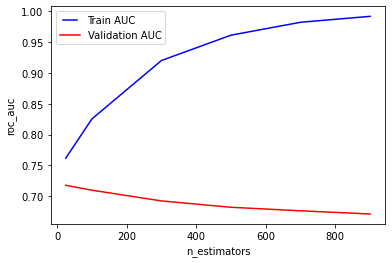

Function tuning_single_hyperparameter Completed Successfully. Exited this function.
NR Estimators : 25 - Train Score : 0.7617999184947083 , Validation Score : 0.7177347290030963
NR Estimators : 100 - Train Score : 0.8254312670233596 , Validation Score : 0.7097729849191844
NR Estimators : 300 - Train Score : 0.9203683746229097 , Validation Score : 0.6923339888356134
NR Estimators : 500 - Train Score : 0.961540279003797 , Validation Score : 0.6820040405767369
NR Estimators : 700 - Train Score : 0.9824938347706169 , Validation Score : 0.67627833263497
NR Estimators : 900 - Train Score : 0.9921194939300182 , Validation Score : 0.6710586481987187


In [68]:
from xgboost import XGBClassifier

s = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
estimator = XGBClassifier(random_state=1, scale_pos_weight=s)

space = [25, 100, 300, 500, 700, 900]

train_scores, val_scores = tuning_single_hyperparameter(estimator, 'XGBoost/', X_train, y_train, 
                                                        hyperparameter_name='n_estimators',
                                                        hyperparameter_space=space, scoring='roc_auc', cv=5, verbose=False)

for x, train_score, val_score in zip(space, train_scores, val_scores):
    print(f'NR Estimators : {x} - Train Score : {train_score} , Validation Score : {val_score}')

* A good space of nr_estimators would be 25-100.

Entered function tuning_single_hyperparameter.


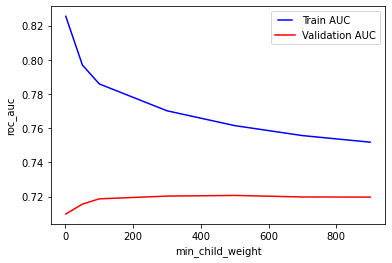

Function tuning_single_hyperparameter Completed Successfully. Exited this function.
Min Child Weight : 1 - Train Score : 0.8254312670233596 , Validation Score : 0.7097729849191844
Min Child Weight : 50 - Train Score : 0.7969569595820335 , Validation Score : 0.7155539102195978
Min Child Weight : 100 - Train Score : 0.7858788755320696 , Validation Score : 0.7186483191112252
Min Child Weight : 300 - Train Score : 0.7701620849239814 , Validation Score : 0.7202540939698083
Min Child Weight : 500 - Train Score : 0.7614957608766731 , Validation Score : 0.7206495050499679
Min Child Weight : 700 - Train Score : 0.7556561379783098 , Validation Score : 0.7197472223521645
Min Child Weight : 900 - Train Score : 0.7518039811332423 , Validation Score : 0.7196613362283033


In [69]:
s = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
estimator = XGBClassifier(random_state=1, scale_pos_weight=s)

space = [1, 50, 100, 300, 500, 700, 900]

train_scores, val_scores = tuning_single_hyperparameter(estimator, 'XGBoost/', X_train, y_train, 
                                                        hyperparameter_name='min_child_weight',
                                                        hyperparameter_space=space, scoring='roc_auc', cv=5, verbose=False)

for x, train_score, val_score in zip(space, train_scores, val_scores):
    print(f'Min Child Weight : {x} - Train Score : {train_score} , Validation Score : {val_score}')

* A good space of min_child_weight would be 300-500.

Entered function best_single_model. 
Entered function evaluate_model_cross_validation.
Function evaluate_model_cross_validation Completed Successfully.Exited this function.
Entered the function train_model
[10:09:26] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Function train_model Completed Successfully! Exited this function.
Default Model Performance on TEST SET : 
Entered function evaluate_model.
              precision    recall  f1-score   support

           0       0.89      0.68      0.77     25930
           1       0.30      0.62      0.41      5711

    accuracy                           0.67     31641
   macro avg       0.60      0.65      0.59     31641
weighted avg       0.79      0.67      0.71     31641

Function evaluat

{'Model Name': 'XGBoostClassifier',
 'Default Model Object': XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
               colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
               importance_type='gain', interaction_constraints='',
               learning_rate=0.300000012, max_delta_step=0, max_depth=6,
               min_child_weight=1, missing=nan, monotone_constraints='()',
               n_estimators=100, n_jobs=8, num_parallel_tree=1, random_state=1,
               reg_alpha=0, reg_lambda=1, scale_pos_weight=4.55683117797132,
               subsample=1, tree_method='exact', validate_parameters=1,
               verbosity=None),
 'Default Model Test Score': 0.6526298866545525,
 'Default Model Training Score': 0.7307575953608277,
 'Default Model CV Mean Score': 0.7097729849191844,
 'Default Model CV Scores': array([0.7079076 , 0.70770673, 0.71133156, 0.70716453, 0.71475451]),
 'Tuned Model Object': XGBClassifier(base_score=0.5, booster='gbtree

<Figure size 1080x864 with 0 Axes>

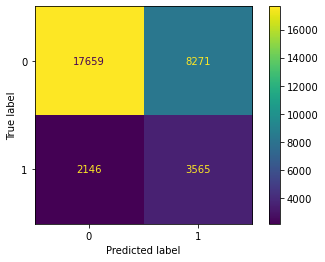

<Figure size 1080x864 with 0 Axes>

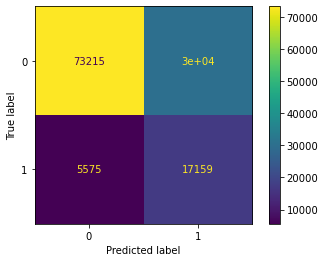

<Figure size 1080x864 with 0 Axes>

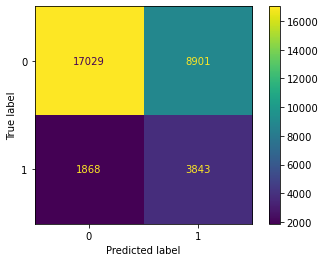

<Figure size 1080x864 with 0 Axes>

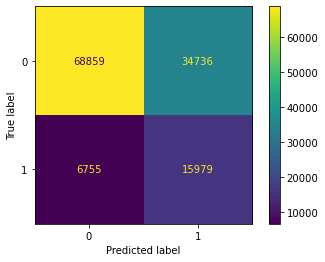

In [72]:
s = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
default_estimator = XGBClassifier(random_state=1, scale_pos_weight=s)

params = {'n_estimators' : [25, 50, 75, 100],
          'learning_rate' : np.linspace(0.01, 0.2, 6)[:-1][1:],
          'max_depth' : [2, 5, 7, 10],
          'subsample' : np.linspace(0.5, 1, 6)[:-1][1:],
          'colsample_bytree' : np.linspace(0.5, 1, 6)[:-1][1:],
          'min_child_weight' : [300, 400, 500]}

dic = best_single_model_RandomizedSearchCV(X_train, y_train, X_test, y_test, model_name='XGBoostClassifier',
                        defaultModel=default_estimator, params=params, cv_scoring='roc_auc', cv_kfold=5, cv_n_iter=30)
dic

* The training and test accuracy are similar so our model is not overfitting. (no need to use early stopping)

In [73]:
best_xgboost = dic['Final Best Model Object']
best_xgboost

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.9, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.12399999999999999, max_delta_step=0, max_depth=7,
              min_child_weight=300, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=8, num_parallel_tree=1, random_state=1,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=4.55683117797132,
              subsample=0.7, tree_method='exact', validate_parameters=1,
              verbosity=None)

In [74]:
best_xgboost_score = dic['Final Best Test Score']
best_xgboost_score

0.6648207905623637

## 2. Attempt : Tuning Random Forest using class_weight attribute

* Since we assign weights to each class (higher weight to class with low frequency and low weight to class with heigh frequency) we must not use any resampling technique.

In [70]:
from sklearn.ensemble import RandomForestClassifier

Entered function tuning_single_hyperparameter.


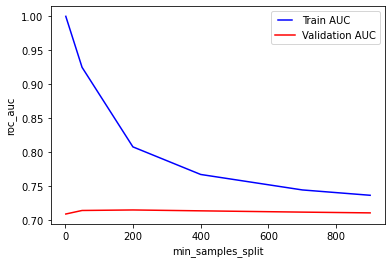

Function tuning_single_hyperparameter Completed Successfully. Exited this function.
Min Samples Split : 2 - Train Score : 1.0 , Validation Score : 0.7093291778296467
Min Samples Split : 50 - Train Score : 0.9250206658917689 , Validation Score : 0.7145284876311111
Min Samples Split : 200 - Train Score : 0.8080492717067701 , Validation Score : 0.7152784635543549
Min Samples Split : 400 - Train Score : 0.7674784929371504 , Validation Score : 0.7140001504426848
Min Samples Split : 700 - Train Score : 0.7447236525970403 , Validation Score : 0.7121060202378875
Min Samples Split : 900 - Train Score : 0.736865628715967 , Validation Score : 0.7109961418746428


In [78]:
estimator = RandomForestClassifier(random_state=1, n_estimators=400)

space = [2, 50, 200, 400, 700, 900]

train_scores, val_scores = tuning_single_hyperparameter(estimator, 'RandomForest/', X_train, y_train,
                                                        'min_samples_split', space, 'roc_auc',  5, graph=True)

for x, train_score, val_score in zip(space, train_scores, val_scores):
    print(f'Min Samples Split : {x} - Train Score : {train_score} , Validation Score : {val_score}')

* A good space of min_samples_split would be 50-200.

Entered function tuning_single_hyperparameter.


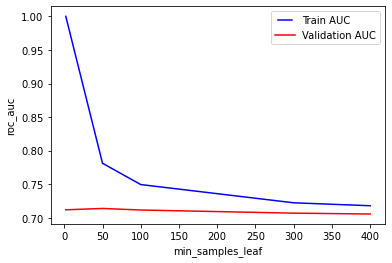

Function tuning_single_hyperparameter Completed Successfully. Exited this function.
Min Samples Leaf : 2 - Train Score : 0.9999965195900893 , Validation Score : 0.7120407797757915
Min Samples Leaf : 50 - Train Score : 0.7813080674331438 , Validation Score : 0.7140345065458381
Min Samples Leaf : 100 - Train Score : 0.7496111799648094 , Validation Score : 0.7117275078489043
Min Samples Leaf : 300 - Train Score : 0.7224769409404711 , Validation Score : 0.7070568375081565
Min Samples Leaf : 400 - Train Score : 0.7180844601312415 , Validation Score : 0.7057773258131802


In [77]:
estimator = RandomForestClassifier(random_state=1, n_estimators=400)

space = [1, 50, 100, 300, 400]

train_scores, val_scores = tuning_single_hyperparameter(estimator, 'RandomForest/', X_train, y_train,
                                                        'min_samples_leaf', space, 'roc_auc',  5)

for x, train_score, val_score in zip(space, train_scores, val_scores):
    print(f'Min Samples Leaf : {x} - Train Score : {train_score} , Validation Score : {val_score}')

* A good space of min_samples_leaf would be 1-50.

In [82]:
y_test.value_counts()

0    25930
1     5711
Name: Bad_Loan, dtype: int64

Entered function best_single_model_RandomizedSearchCV. 
Entered function evaluate_model_cross_validation.
Function evaluate_model_cross_validation Completed Successfully.Exited this function.
Entered the function train_model
Function train_model Completed Successfully! Exited this function.
Default RandomForestClassifier Model Performance on TEST SET : 
Entered function evaluate_model_classification.
              precision    recall  f1-score   support

           0       0.82      0.99      0.90     25930
           1       0.46      0.03      0.06      5711

    accuracy                           0.82     31641
   macro avg       0.64      0.51      0.48     31641
weighted avg       0.76      0.82      0.75     31641

Function evaluate_model_classification Completed Successfully. Exited this function
Default RandomForestClassifier Model Performance on TRAINING SET : 
Entered function evaluate_model_classification.
              precision    recall  f1-score   support

           0  

{'Model Name': 'RandomForestClassifier',
 'Default Model Object': RandomForestClassifier(n_estimators=400, random_state=1),
 'Default Model Test Score': 0.5110463039000993,
 'Default Model Training Score': 1.0,
 'Default Model CV Mean Score': 0.6975415197880522,
 'Default Model CV Scores': array([0.69344254, 0.69691839, 0.70306214, 0.69195397, 0.70233056]),
 'Tuned Model Object': RandomForestClassifier(class_weight={0: 0.3833333333333333,
                                      1: 0.6166666666666667},
                        criterion='entropy', max_features='log2',
                        min_samples_leaf=5, min_samples_split=150,
                        n_estimators=400, random_state=1),
 'Best Hyperparameters': {'min_samples_split': 150,
  'min_samples_leaf': 5,
  'max_features': 'log2',
  'criterion': 'entropy',
  'class_weight': {0: 0.3833333333333333, 1: 0.6166666666666667}},
 'Tuned Model CV Mean Score': 0.7065857929243623,
 'Tuned Model CV Scores': array([0.70159894, 0.70653478, 

<Figure size 1080x864 with 0 Axes>

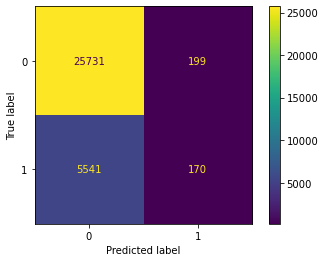

<Figure size 1080x864 with 0 Axes>

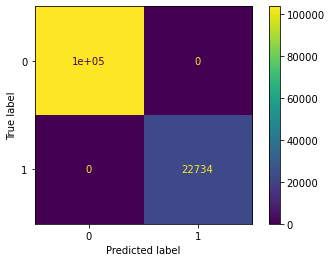

<Figure size 1080x864 with 0 Axes>

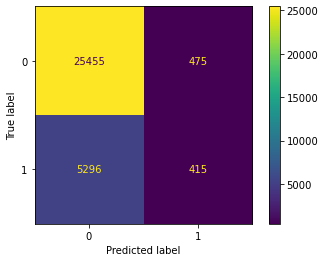

<Figure size 1080x864 with 0 Axes>

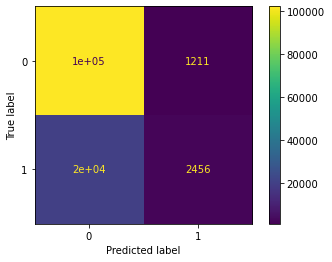

In [78]:
estimator = RandomForestClassifier(random_state=1, n_estimators=400)

weights = np.linspace(0.05, 0.45, 7)[:-1][1:]

params = {'class_weight' : [{0:x, 1:1-x} for x in weights],
          'max_features' : ['sqrt', 'log2', None],
          'min_samples_split' : [50, 100, 150, 200],
          'min_samples_leaf' : [5, 20, 40, 50],
          'criterion' : ['gini', 'entropy']}

dic = best_single_model_RandomizedSearchCV(X_train, y_train, X_test, y_test, model_name='RandomForestClassifier',
                        defaultModel=estimator, params=params, cv_scoring='roc_auc', cv_kfold=5, cv_n_iter=30)
dic

## 3. Attempt : Easy Ensemble Classifier

In [87]:
from imblearn.ensemble import EasyEnsembleClassifier
from xgboost import XGBClassifier

Entered function best_single_model_RandomizedSearchCV. 
Entered function evaluate_model_cross_validation.
Function evaluate_model_cross_validation Completed Successfully.Exited this function.
Entered the function train_model
Function train_model Completed Successfully! Exited this function.
Default EasyEnsembleClassifier Model Performance on TEST SET : 
Entered function evaluate_model_classification.
              precision    recall  f1-score   support

           0       0.90      0.64      0.75     25930
           1       0.29      0.67      0.40      5711

    accuracy                           0.65     31641
   macro avg       0.59      0.65      0.58     31641
weighted avg       0.79      0.65      0.69     31641

Function evaluate_model_classification Completed Successfully. Exited this function
Default EasyEnsembleClassifier Model Performance on TRAINING SET : 
Entered function evaluate_model_classification.
              precision    recall  f1-score   support

           0  

{'Model Name': 'EasyEnsembleClassifier',
 'Default Model Object': EasyEnsembleClassifier(base_estimator=XGBClassifier(base_score=None,
                                                     booster=None,
                                                     colsample_bylevel=None,
                                                     colsample_bynode=None,
                                                     colsample_bytree=None,
                                                     gamma=None, gpu_id=None,
                                                     importance_type='gain',
                                                     interaction_constraints=None,
                                                     learning_rate=None,
                                                     max_delta_step=None,
                                                     max_depth=None,
                                                     min_child_weight=None,
                                       

<Figure size 1080x864 with 0 Axes>

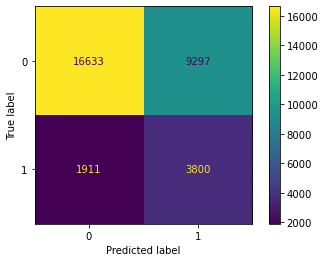

<Figure size 1080x864 with 0 Axes>

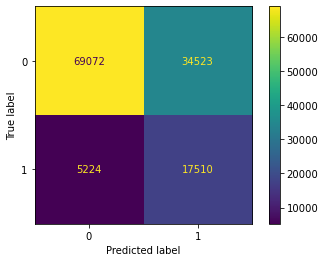

<Figure size 1080x864 with 0 Axes>

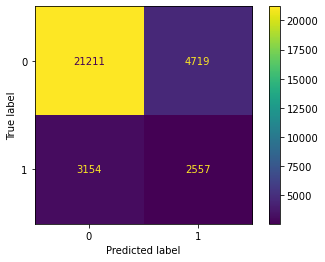

<Figure size 1080x864 with 0 Axes>

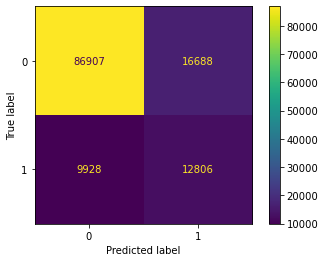

In [88]:
default_estimator = EasyEnsembleClassifier(random_state=1, base_estimator=XGBClassifier(random_state=1),
                                           n_jobs=-1)

params = {'sampling_strategy' : np.linspace(0.1, 1, 6)}

dic = best_single_model_RandomizedSearchCV(X_train, y_train, X_test, y_test, model_name='EasyEnsembleClassifier',
                        defaultModel=default_estimator, params=params, cv_scoring='roc_auc', cv_kfold=5, cv_n_iter=30)
dic

In [ ]:
best_easyensemble = dic['Final Best Model Object']
best_easyensemble

In [ ]:
best_easyensemble_test_score = dic['Final Best Test Score']
best_easyensemble_test_score

## 4. Attempt : Combination of Oversampling and Undersampling using SMOTETomek

In [69]:
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline

In [ ]:
pipeline = Pipeline([('smotetomek', SMOTETomek(random_state=1, n_jobs=-1)),
                     ('estimator', XGBClassifier(random_state=1, n_jobs=-1))])

params = {'smotetomek__sampling_strategy' : np.linspace(0.2, 1, 6),
          'estimator__n_estimators' : [50, 100, 300, 500, 700],
          'estimator__learning_rate' : np.linspace(0.01, 0.2, 6)[:-1][1:],
          'estimator__max_depth' : [3, 5, 7, 10],
          'estimator__subsample' : np.linspace(0.5, 1, 6)[:-1][1:],
          'estimator__colsample_bytree' : np.linspace(0.5, 1, 6)[:-1][1:],
          'estimator__min_child_weight' : [1, 15, 50, 100, 200]}

dic = best_single_model_RandomizedSearchCV(X_train, y_train, X_test, y_test, model_name='XGBoostClassifier',
                        defaultModel=pipeline, params=params, cv_scoring='roc_auc', cv_kfold=5, cv_n_iter=30)
dic

Entered function best_single_model_RandomizedSearchCV. 
Entered function evaluate_model_cross_validation.
Function evaluate_model_cross_validation Completed Successfully.Exited this function.
Entered the function train_model
[20:53:42] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Function train_model Completed Successfully! Exited this function.
Default XGBoostClassifier Model Performance on TEST SET : 
Entered function evaluate_model_classification.
              precision    recall  f1-score   support

           0       0.83      0.98      0.90     25930
           1       0.47      0.08      0.14      5711

    accuracy                           0.82     31641
   macro avg       0.65      0.53      0.52     31641
weighted avg       

## Find Best ML Estimator out of many estimators.

In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.ensemble import EasyEnsembleClassifier
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import pandas as pd
import random

def best_model_OutOfManyModels_RandomizedSearchCV(X_train, y_train, X_test, y_test, cv_scoring, cv_kfold=5, 
                                                  cv_niter=20, verbose=False):
    try:
        print('Entered the function best_model_OutOfManyModels_RandomizedSearchCV.')
    
        # model_df is dataframe which containss information about training and testing of each model
        model_df = pd.DataFrame()
        
        # dic is a dictionary which contains the best model object found for each ML algorithms and its score
        dic = {}
        
    
        # 1. Attempt : XGBoost Model using scale_pos_weigt attribute
        s = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
        default_xgboost = XGBClassifier(random_state=1, scale_pos_weight=s, n_jobs=-1)

        params_xgboost = {'n_estimators' : [25, 50, 75, 100],
                  'learning_rate' : np.linspace(0.01, 0.2, 6)[:-1][1:],
                  'max_depth' : [2, 5, 7, 10],
                  'subsample' : np.linspace(0.5, 1, 6)[:-1][1:],
                  'colsample_bytree' : np.linspace(0.5, 1, 6)[:-1][1:],
                  'min_child_weight' : [300, 400, 500]}

        print('XGBoost Tuning')
        xgboost_infos = best_single_model_RandomizedSearchCV(X_train, y_train, X_test, y_test, model_name='XGBoostClassifier',
                                          defaultModel=default_xgboost, params=params_xgboost, 
                                          cv_scoring='roc_auc', cv_kfold=5, cv_n_iter=30)
        
        model_df = model_df.append(xgboost_infos, ignore_index=True)
        
        # Get Best XGBoost Model Object and its Test score
        best_xgboost_object = xgboost_infos['Final Best Model Object']
        best_xgboost_test_score = xgboost_infos['Final Best Test Score']
        # Add the information to the dictionary
        dic[best_xgboost_object] = best_xgboost_test_score
      
    
        # Attempt 2 : Random Forest using class_weight attribute
        default_randomforest = RandomForestClassifier(random_state=1, n_estimators=400)

        weights = np.linspace(0.05, 0.45, 7)[:-1][1:]

        params_randomforest = {'class_weight' : [{0:x, 1:1-x} for x in weights],
                               'max_features' : ['sqrt', 'log2', None],
                               'min_samples_split' : [50, 100, 150, 200],
                               'min_samples_leaf' : [5, 20, 40, 50],
                               'criterion' : ['gini', 'entropy'],
                               'bootstrap' : [True, False]}
        
        print('Random Forest Tuning')
        randomforest_infos = best_single_model_RandomizedSearchCV(X_train, y_train, X_test, y_test, model_name='RandomForestClassifier',
                                          defaultModel=default_randomforest, params=params_randomforest, 
                                          cv_scoring='roc_auc', cv_kfold=5, cv_n_iter=30)
        
        # Add the RandomForest Infos to the dataframe
        model_df = model_df.append(randomforest_infos, ignore_index=True)
        # Get Best RandomForest Model Object and its test score
        best_randomforest_object = randomforest_infos['Final Best Model Object']
        best_randomforest_test_score = randomforest_infos['Final Best Test Score']
        # Add the information to the dictionary
        dic[best_randomforest_object] = best_randomforest_test_score
        
        
        # 3. Attempt : Easy Ensemble Classifier
        default_easyensemble = EasyEnsembleClassifier(random_state=1, base_estimator=XGBClassifier(random_state=1),
                                           n_jobs=-1)

        params_easyensemble = {'sampling_strategy' : np.linspace(0.1, 1, 6)}
        
        print('Easy Ensemble Tuning')
        knn_infos = best_single_model_RandomizedSearchCV(X_train, y_train, X_test, y_test, model_name='EasyEnsembleClassifier',
                                      defaultModel=default_easyensemble, params=params_easyensemble, 
                                      cv_scoring='roc_auc', cv_kfold=5, cv_n_iter=30)
        
        # Add the knn infos to the dataframe
        model_df = model_df.append(knn_infos, ignore_index=True)
        # Get Best KNN Model Object and its test score
        best_knn_object = knn_infos['Final Best Model Object']
        best_knn_test_score = knn_infos['Final Best Test Score']
        # Add the information to the dictionary
        dic[best_knn_object] = best_knn_test_score
        
        
        # 4. Attempt : Combination of Oversampling and Undersampling using SMOTETomek
        
        default_ou = Pipeline([('smotetomek', SMOTETomek(random_state=1, n_jobs=-1)),
                     ('estimator', XGBClassifier(random_state=1, n_jobs=-1))])

        params_ou = {'smotetomek__sampling_strategy' : np.linspace(0.2, 1, 6),
                     'estimator__n_estimators' : [50, 100, 300, 500, 700],
                     'estimator__learning_rate' : np.linspace(0.01, 0.2, 6)[:-1][1:],
                     'estimator__max_depth' : [3, 5, 7, 10],
                     'estimator__subsample' : np.linspace(0.5, 1, 6)[:-1][1:],
                     'estimator__colsample_bytree' : np.linspace(0.5, 1, 6)[:-1][1:],
                     'estimator__min_child_weight' : [1, 15, 50, 100, 200]}

        ou_infos = best_single_model_RandomizedSearchCV(X_train, y_train, X_test, y_test, model_name='XGBoostOverUnderSampling',
                        defaultModel=default_ou, params=params_ou, cv_scoring='roc_auc', cv_kfold=5, cv_n_iter=30)

        # Add the knn infos to the dataframe
        model_df = model_df.append(ou_infos, ignore_index=True)
        # Get Best KNN Model Object and its test score
        best_ou_object = ou_infos['Final Best Model Object']
        best_ou_test_score = ou_infos['Final Best Test Score']
        # Add the information to the dictionary
        dic[best_ou_object] = best_ou_test_score
        
        
        # save information about all models into a csv file and the information about xgboost in separate file if we have used early stopping
        model_df.to_csv('model_infos.csv', index=False)
    
    
       # Finding best model out of all models based on test score
        best_model_object = max(dic, key=dic.get)
        best_test_score = max(dic.values())

        try:

            print('Function best_model_OutOfManyModels_RandomizedSearchCV Completed Successfully. Exited this function.')
            return best_model_object, str(best_model_object.named_steps['estimator']).split('(')[0], best_test_score

        except Exception as e:
            return best_model_object, str(best_model_object).split('(')[0], best_test_score
        
        
    
    
    except Exception as e:
        print('Error occured in function best_model_OutOfManyModels_RandomizedSearchCV. Error Message : ' + str(e))

In [ ]:
best_model, best_model_name, best_test_score = best_model_OutOfManyModels_RandomizedSearchCV(X_train, y_train, 
                                                                                             X_test, y_test, 
                                                                                             cv_scoring='roc_auc')
bm

Entered the function best_model_OutOfManyModels_RandomizedSearchCV.
XGBoost Tuning
Entered function best_single_model_RandomizedSearchCV. 
Entered function evaluate_model_cross_validation.
Function evaluate_model_cross_validation Completed Successfully.Exited this function.
Entered the function train_model
[11:36:47] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Function train_model Completed Successfully! Exited this function.
Default XGBoostClassifier Model Performance on TEST SET : 
Entered function evaluate_model_classification.
              precision    recall  f1-score   support

           0       0.89      0.68      0.77     25930
           1       0.29      0.61      0.40      5711

    accuracy                           0.67 

### Step 8 : Save the model, export the encoded_features dictionary and other variables that we need for prediction

In [ ]:
import pickle
import os
import shutil

def save_model(model,filename):
    try:
        print('Entered the function save_model.')
        
        model_directory = 'models/'
        if os.path.isdir(model_directory) == False:
            os.makedirs(model_directory)
            
        path = os.path.join(model_directory,filename) 
        if os.path.isdir(path):
            shutil.rmtree(path)
            os.makedirs(path)
        else:
            os.makedirs(path)

        with open(path +'/' + filename+'.sav', 'wb') as f:
            pickle.dump(model, f) 


        print('Function save_model Completed Successfully.')

        return 'success'
    
    except Exception as e:
        print('Error occured in function save_model. Exited this function.')

In [ ]:
save_model(best_model, best_model_name)

In [75]:
# Export the encoded_features dictionary

import json

with open("encoded_features.json","w") as f:
    f.write(json.dumps(encoded_features))

In [76]:
# Export the dic_state dictionary


with open("dic_state.json","w") as f:
    f.write(json.dumps(dic_state))

### Step 9 : Make predictions on new unseen data

1. First i will load the model and the encoded_features dictionary that we need to preprocess input features from user before making predictions. <br>
2. I will preprocess (encode) the input features following the order of the features when training happended and create a list for each feature.
3. I will append all lists into 1 single list which will be the entire input X of all features and predict using the model.

**A) When we create the encoded_Features dictionarty we follow the order of the columns in updated_cols. We must follow the order of the features in encoded_features/updated_cols when we pass input x to our ML Estimator for prediction.** <br>
**B) We must take into consideration the feautures X and their order after the entire data preprocessing, right before starting training.** <br>
**C) We must encode the features like we did in data preprocessing.**<br>
**D) We must perform any data transformation (in our case gaussian transformation and standardscaler) before we make prediction.** <br>
**E) It is a good idea to convert the input data from html form into the datatype that was used during training those features.** <br>
**F) The X features that we pass to our ML Estimator must be a 2D Array (in best case numpy array instead of python list to avoid any error).** <br>
**G) The number of input in the html format is equal to the nr of columns before data preprocessing (real_cols) excluding columns that were removing during feature selection.** <br>
**H) When creating the html form if we want to create for example 4 rows with 3 column we use 4 class='row' divs where each of them has 3 divs class='columns'. Those combined with the css code.** <br>
**I) If we want to create options for a select and there are too many categories in a feature we can use for loop and copy paste the code.** <br>
**J) If we have a float number html input we must specify attribute for example step='0.01'.** 

* real_cols is a list that has the column names before preprocessing. We will use these columns as input data that we take from the user.
* cols_unique_values is a dictionary that has the unique values for each column (before preprocessing). We need them to create the input data in the html form.
* encoded_features is a dictionary that has for each feature the encoded features created; for example from area_type are created 3 one-hot encoded features. We need them to encode the input data we take from the user and preprocess it.
* updated_cols is the updated list of columns (after preprocessing).

* If we have performed One Hot Encoding with Categories Reduction TEchnique we take the input values from the encoded_features dictionary for that particular feature. If we have performed one hot encoding in the entire data, we take only 'xyz' from 'feature_xyz'. Otherwise, if we have performed one hot encoding in single feature and then concatenate we take entire value.

In [77]:
real_cols

['RowID',
 'Loan_Amount',
 'Term',
 'Interest_Rate',
 'Employment_Years',
 'Home_Ownership',
 'Annual_Income',
 'Verification_Status',
 'Loan_Purpose',
 'State',
 'Debt_to_Income',
 'Delinquent_2yr',
 'Revolving_Cr_Util',
 'Total_Accounts',
 'Longest_Credit_Length']

In [78]:
updated_cols

Index(['Loan_Amount', 'Term', 'Interest_Rate', 'Employment_Years',
       'Annual_Income', 'State', 'Debt_to_Income', 'Delinquent_2yr',
       'Revolving_Cr_Util', 'Total_Accounts', 'Longest_Credit_Length',
       'Home_Ownership_MORTGAGE', 'Home_Ownership_OWN', 'Home_Ownership_RENT',
       'Verification_Status_VERIFIED - income',
       'Verification_Status_VERIFIED - income source',
       'Verification_Status_not verified', 'Loan_Purpose_car',
       'Loan_Purpose_credit_card', 'Loan_Purpose_debt_consolidation',
       'Loan_Purpose_educational', 'Loan_Purpose_home_improvement',
       'Loan_Purpose_house', 'Loan_Purpose_major_purchase',
       'Loan_Purpose_medical', 'Loan_Purpose_moving', 'Loan_Purpose_other',
       'Loan_Purpose_renewable_energy', 'Loan_Purpose_small_business',
       'Loan_Purpose_vacation', 'Loan_Purpose_wedding'],
      dtype='object')

In [79]:
def load_model(filename):
    try:
        model_directory = 'models/'
        print('Entered function load_model.')

        with open(model_directory + filename + '/' + filename + '.sav', 'rb') as f:
            print('Function load_model Completed Succesfully. Exited this function.')
            return pickle.load(f)
    
    except Exception as e:
        print('Error occured in function load_model. Error Message : ' + str(e))

In [95]:
load_model(best_model_name)

Entered function load_model.
Function load_model Completed Succesfully. Exited this function.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.300000012, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=8, num_parallel_tree=1, random_state=1,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=4.55683117797132,
              subsample=1, tree_method='exact', validate_parameters=1,
              verbosity=None)

In [80]:
cols_unique_values['Verification_Status']

array(['VERIFIED - income', 'VERIFIED - income source', 'not verified',
       nan], dtype=object)

In [81]:
encoded_features

{'Loan_Amount': ['Loan_Amount'],
 'Term': ['Term'],
 'Interest_Rate': ['Interest_Rate'],
 'Employment_Years': ['Employment_Years'],
 'Annual_Income': ['Annual_Income'],
 'State': ['State'],
 'Debt_to_Income': ['Debt_to_Income'],
 'Delinquent_2yr': ['Delinquent_2yr'],
 'Revolving_Cr_Util': ['Revolving_Cr_Util'],
 'Total_Accounts': ['Total_Accounts'],
 'Longest_Credit_Length': ['Longest_Credit_Length'],
 'Home_Ownership': ['Home_Ownership_MORTGAGE',
  'Home_Ownership_OWN',
  'Home_Ownership_RENT'],
 'Verification_Status': ['Verification_Status_VERIFIED - income',
  'Verification_Status_VERIFIED - income source',
  'Verification_Status_not verified'],
 'Loan_Purpose': ['Loan_Purpose_car',
  'Loan_Purpose_credit_card',
  'Loan_Purpose_debt_consolidation',
  'Loan_Purpose_educational',
  'Loan_Purpose_home_improvement',
  'Loan_Purpose_house',
  'Loan_Purpose_major_purchase',
  'Loan_Purpose_medical',
  'Loan_Purpose_moving',
  'Loan_Purpose_other',
  'Loan_Purpose_renewable_energy',
  'Loa

In [107]:
def predict_loan(loan_amount_form, term_form, interest_rate_form, employment_years_form, annual_income_form,
                 state_form, debt_to_income_form, delinquent_2yr_form, revolving_cr_util_form, total_accounts_form,
                 longest_credit_length_form, home_ownership_form, verification_status_form, loan_purpose_form):
    
    # load the model
    model = load_model('XGBoost')
    
    # load the encoded features dictionary
    with open('encoded_features.json', 'r') as myfile:
        encoded_features_str = myfile.read()
        encoded_features = json.loads(encoded_features_str)
        
    
    # Features Preprocessing
    
    # Preprocess loan_amount 
    # (no need to preprocess loan_amount since it will be a number. i will just convert to float)
    loan_amount = float(loan_amount_form)
    loan_amount_list = [loan_amount]
    
    # Preprocess term
    # term will either be '36 months' or 60 'months'. I will convert it to int since the datatype of this feature when training happend was int
    term_tokens = term_form.split('months')
    term = int(term_tokens[0])
    term_list = [term]
    
    # Preprocess interest_rate
    # no need to preprocess interest_rate since it is a number. i will just convert it to float
    interest_rate = float(interest_rate_form)
    interest_rate_list = [interest_rate]
    
    
    # Preprocess Employment_Years
    # no need to preprocess Employment_Years since it is a number, i will just convert it to float
    employment_years = float(employment_years_form)
    employment_years_list = [employment_years]
    
    
    # Preprocess Annual_Income
    # no need to preprocess Annual_Income sinnce it is a number. I will just convert it to float
    annual_income = float(annual_income_form)
    annual_income_list = [annual_income]
    
    
    # Preprocess State
    # load the dic_state dictionary
    with open('dic_state.json', 'r') as myfile:
        dic_state_str = myfile.read()
        dic_state = json.loads(dic_state_str)
        
    state = dic_state[state_form]
    state_list = [state]
    
    # Preprocess debt_to_income
    debt_to_income = float(debt_to_income_form)
    debt_to_income_list = [debt_to_income]
    
    # Preprocess Delinquent_2yr
    # no need to preprocess Delinquent_2yr since it is a number. I will just convert it to float.
    delinquent_2yr = float(delinquent_2yr_form)
    delinquent_2yr_list = [delinquent_2yr]
    
    # Preprocess Revolving_Cr_Util
    # no need to preprocess Revolving_Cr_Util since it is a number. I will just convert it to float.
    revolving_cr_util = float(revolving_cr_util_form)
    revolving_cr_util_list = [revolving_cr_util]
    
    
    # Preprocess Total_Accounts
    # no need to preprocess Total_Accounts since it is a number. I will just convert it to float.
    total_accounts = float(total_accounts_form)
    total_accounts_list = [total_accounts]
    
    
    # Preprocess Longest_Credit_Length
    # no need to preprocess Longest_Credit_Length since it is a number. I will just convert it to float
    longest_credit_length = float(longest_credit_length_form)
    longest_credit_length_list = [longest_credit_length]
    
    
    # Preprocess Home_Ownership
    if home_ownership_form == 'RENT':
        Home_Ownership_MORTGAGE = 0
        Home_Ownership_OWN = 0
        Home_Ownership_RENT = 1
    elif home_ownership_form == 'OWN':
        Home_Ownership_MORTGAGE = 0
        Home_Ownership_OWN = 1
        Home_Ownership_RENT = 0
    elif home_ownership_form == 'MORTGAGE':
        Home_Ownership_MORTGAGE = 1
        Home_Ownership_OWN = 0
        Home_Ownership_RENT = 0
    elif home_ownership_form == 'OTHER':
        Home_Ownership_MORTGAGE = 0
        Home_Ownership_OWN = 0
        Home_Ownership_RENT = 0
    elif home_ownership_form == 'NONE':
        Home_Ownership_MORTGAGE = 0
        Home_Ownership_OWN = 0
        Home_Ownership_RENT = 0
        
    home_ownership_list = [Home_Ownership_MORTGAGE,  Home_Ownership_OWN, Home_Ownership_RENT]
    
    
    # Preprocess Verification Status    
    if verification_status_form == 'VERIFIED - income':
        Verification_Status_VERIFIED_income = 1 
        Verification_Status_VERIFIED_income_source = 0
        Verification_Status_not_verified = 0
    elif verification_status_form == 'VERIFIED - income source':
        Verification_Status_VERIFIED_income = 0
        Verification_Status_VERIFIED_income_source = 1
        Verification_Status_not_verified = 0
    elif verification_status_form == 'not verified':
        Verification_Status_VERIFIED_income = 0
        Verification_Status_VERIFIED_income_source = 0
        Verification_Status_not_verified = 1
        
    verification_status_list = [Verification_Status_VERIFIED_income , Verification_Status_VERIFIED_income_source,
                                Verification_Status_not_verified]
    
    
    # Preprocess Loan Purpose
    new_loan_purpose = 'Loan_Purpose_' + loan_purpose_form
    encoded_loan_purpose = encoded_features['Loan_Purpose']
    loan_purpose_vec = np.zeros(len(encoded_loan_purpose))
    for i in range(len(encoded_loan_purpose)):
        if encoded_loan_purpose[i] == new_loan_purpose:
            loan_purpose_vec[i] = 1
        
    loan_purpose_list = list(loan_purpose_vec)

    # append all inputs into a single list
    X = loan_amount_list + term_list + interest_rate_list + employment_years_list + annual_income_list + state_list + debt_to_income_list + delinquent_2yr_list + revolving_cr_util_list + total_accounts_list + longest_credit_length_list + home_ownership_list + verification_status_list + loan_purpose_list  
    X_arr = np.array([X]) # convert list to numpy array
    pred = model.predict(X_arr)
    
    if pred[0] == 1:
        return 'BAD LOAN. LOAN DISSAPROVAL!'
    else:
        return 'GOOD LOAN. LOAN APPROVAL!'
    

In [108]:
predict_loan('5000.0', '36 months', 10.65, 10.0, 24000, 'AZ', 27.65, 0.0, 83.7, 9.0, 26.0, 'RENT', 'VERIFIED - income', 'credit_card')

Entered function load_model.
Function load_model Completed Succesfully. Exited this function.


'BAD LOAN. LOAN DISSAPROVAL!'

In [268]:
cols_unique_values

{'RowID': array([     1,      2,      3, ..., 163992, 163993, 163994], dtype=int64),
 'Loan_Amount': array([ 5000.,  2500.,  2400., ..., 26525., 29150., 26875.]),
 'Term': array(['36 months', '60 months', nan], dtype=object),
 'Interest_Rate': array([10.65, 15.27, 15.96, 13.49,  7.9 , 18.64, 21.28, 12.69, 14.65,
         9.91, 16.29,  6.03, 11.71, 12.42, 14.27, 16.77,  7.51,  8.9 ,
        18.25,  6.62, 19.91, 17.27, 17.58, 21.67, 19.42, 20.89, 20.3 ,
        23.91, 19.03, 23.13, 22.35, 22.06, 24.11, 22.74,  6.  , 23.52,
        22.11,  7.49, 11.99,  5.99, 10.99,  9.99, 18.79, 11.49,  8.49,
        15.99, 16.49,  6.99, 15.23, 14.79,  5.42, 10.59, 17.49, 15.62,
        19.29, 12.99, 13.99, 16.89, 17.99, 20.99, 22.85, 19.69, 18.39,
        20.62, 20.25, 21.36, 23.22, 21.74, 22.48, 23.59, 12.62, 18.07,
        11.63,  7.91,  7.42, 11.14, 20.2 , 12.12, 19.39, 16.11, 17.54,
        22.64, 13.84, 16.59, 17.19, 12.87, 20.69,  9.67, 21.82, 19.79,
        18.49, 22.94, 24.4 , 21.48, 14.82, 14.1

In [272]:
for x in cols_unique_values['State']:
    print(f"<option value='{x}'>{x}</option>")

<option value='AZ'>AZ</option>
<option value='GA'>GA</option>
<option value='IL'>IL</option>
<option value='CA'>CA</option>
<option value='TX'>TX</option>
<option value='VA'>VA</option>
<option value='MO'>MO</option>
<option value='CT'>CT</option>
<option value='UT'>UT</option>
<option value='FL'>FL</option>
<option value='NY'>NY</option>
<option value='PA'>PA</option>
<option value='MN'>MN</option>
<option value='NJ'>NJ</option>
<option value='OR'>OR</option>
<option value='KY'>KY</option>
<option value='OH'>OH</option>
<option value='SC'>SC</option>
<option value='RI'>RI</option>
<option value='LA'>LA</option>
<option value='MA'>MA</option>
<option value='WA'>WA</option>
<option value='WI'>WI</option>
<option value='AL'>AL</option>
<option value='NV'>NV</option>
<option value='CO'>CO</option>
<option value='MD'>MD</option>
<option value='WV'>WV</option>
<option value='VT'>VT</option>
<option value='MI'>MI</option>
<option value='DC'>DC</option>
<option value='SD'>SD</option>
<option 